# EDA-NEWS

Notebook ini dipakai untuk memahami kualitas sumber berita dari GDELT sebelum sentiment analysis masuk ke modeling.

Fokus notebook:
1. Melihat apakah hasil query GDELT cukup relevan untuk industri aluminium.
2. Mengukur seberapa besar indikasi noise atau berita yang tidak berguna.
3. Menentukan apakah data berita ini layak dibawa ke tahap sentiment analysis dan XGBoost.

Prinsip penting:
- Notebook ini **belum** melakukan sentiment analysis.
- Notebook ini fokus dulu ke **kualitas sumber berita**.
- Jika query masih terlalu longgar, itu harus diperbaiki di sini dulu sebelum masuk ke model.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from datetime import datetime
from pathlib import Path
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import requests
import time
import re

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 180)


## Cara membaca notebook ini

- Jika hasil `noise` atau `context_only` tinggi, berarti query masih berisiko menarik berita yang tidak relevan.
- Jika hasil `direct` dan `indirect` cukup dominan, berarti sumber GDELT cukup menjanjikan.
- Sampel judul di bagian bawah penting untuk audit manual. Bagian itu sengaja dibuat agar mudah dilihat apakah ada berita absurd atau tidak relevan.


In [2]:
# Resolve project root from either repo root or notebooks/
root_candidates = [Path("."), Path("..")]
PROJECT_ROOT = None
for candidate in root_candidates:
    if (candidate / "data").exists():
        PROJECT_ROOT = candidate.resolve()
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("Folder data/ tidak ditemukan. Jalankan notebook dari root project atau dari folder notebooks/.")

DATA_DIR = PROJECT_ROOT / "data" / "news"
RAW_DIR = DATA_DIR / "raw"
STAGING_DIR = DATA_DIR / "staging"
RAW_DIR.mkdir(parents=True, exist_ok=True)
STAGING_DIR.mkdir(parents=True, exist_ok=True)

RAW_CACHE_PATH = RAW_DIR / "gdelt_eda_raw_v4_precision.csv"
CLEAN_CACHE_PATH = STAGING_DIR / "gdelt_eda_clean_v4_precision.csv"

BASE_URL = "https://api.gdeltproject.org/api/v2/doc/doc"
REFRESH_FROM_GDELT = True
TIMESPAN = "30d"
MAX_RECORDS_PER_CALL = 20
PAUSE_SECONDS = 5
RETRIES = 3
TIMEOUT = 60
JSON_PREVIEW_CHARS = 180
LANGUAGES = ["english", "indonesian"]

COMMODITY_ANCHORS = [
    "aluminium", "aluminum", "alumina", "bauxite", "lme",
]

BUSINESS_DIRECT_TERMS = [
    "aluminium price", "aluminum price", "alumina price", "bauxite price",
    "aluminium premium", "aluminum premium",
    "aluminium market", "aluminum market", "alumina market",
    "lme aluminium", "lme aluminum",
    "aluminium inventory", "aluminum inventory",
    "aluminium tariff", "aluminum tariff",
    "aluminium sanctions", "aluminum sanctions",
    "aluminium export ban", "aluminum export ban",
    "harga aluminium", "harga alumina", "tarif aluminium", "sanksi aluminium",
]

MODEL_SIGNAL_TERMS = [
    "price", "prices", "premium", "market",
    "supply", "demand", "inventory", "stockpile", "warehouse",
    "tariff", "tariffs", "sanctions", "export ban",
    "shipping", "logistics", "freight",
    "force majeure", "production", "output",
    "harga", "pasokan", "permintaan", "produksi", "tarif", "sanksi",
]

INDUSTRY_STRUCTURE_TERMS = [
    "smelter", "refinery", "alumina refinery", "bauxite mine",
    "mining", "capacity", "shutdown", "reopening", "closure",
    "acquire", "acquires", "acquisition", "deal", "agreement",
]

OTHER_METAL_TERMS = [
    "copper", "zinc", "nickel", "steel", "iron ore",
]

PRODUCT_NOISE_TERMS = [
    "ceraluminum",
    "laptop", "notebook", "smartphone", "phone", "tablet",
    "review", "oled", "camera", "android",
    "iphone", "samsung", "asus", "pixel", "xiaomi", "huawei", "oppo", "vivo",
    "watch", "headphone", "earbuds", "bike", "bikes", "bicycle",
    "lighting", "interior", "design", "furniture",
    "health", "recipe", "restaurant", "travel", "magazine", "fashion",
    "movie", "film", "concert", "award", "beverage",
]

EVENT_NOISE_TERMS = [
    "trade fair", "expo", "conference", "represented at",
    "leadership", "leadership pipeline",
    "appointment", "appointed", "executive", "chief",
    "briefing", "dealmaking",
]

FINANCE_NOISE_TERMS = [
    "analysts explain", "price target", "buy rating", "sell rating",
    "stock surges", "stock target", "stock targets", "metal stocks",
    "shares", "stake", "nasdaq", "nyse", "cao sells",
]

NOISE_KEYWORDS = [
    "celebrity", "actor", "actress", "singer", "dating", "selingkuh",
    "instagram", "tiktok", "youtube", "wedding", "divorce", "affair",
] + PRODUCT_NOISE_TERMS + EVENT_NOISE_TERMS + FINANCE_NOISE_TERMS

HIGH_SIGNAL_DOMAINS = {
    "mining.com",
    "hellenicshippingnews.com",
    "news.metal.com",
    "fastmarkets.com",
    "business-standard.com",
}

LOW_SIGNAL_DOMAINS = {
    "finance.yahoo.com",
    "economictimes.indiatimes.com",
    "businesstoday.in",
    "moneycontrol.com",
    "livemint.com",
    "tickerreport.com",
    "bicycleretailer.com",
    "gadget.viva.co.id",
    "eturbonews.com",
    "tradearabia.com",
    "interest.co.nz",
    "themarketsdaily.com",
    "dailypolitical.com",
    "fool.com",
    "insidermonkey.com",
}

QUERY_MAP = {
    "price_lme": '"aluminium price" OR "aluminum price" OR "LME aluminium" OR "LME aluminum"',
    "price_inputs": '"alumina price" OR "bauxite price" OR "aluminium premium" OR "aluminum premium"',
    "supply_assets": '"aluminium smelter" OR "aluminum smelter" OR "alumina refinery" OR "aluminium refinery"',
    "supply_events": '"aluminium supply disruption" OR "aluminum supply disruption" OR "aluminium force majeure" OR "aluminum force majeure"',
    "inventory_warehouse": '"aluminium inventory" OR "aluminum inventory" OR "LME warehouse" OR "aluminium stockpile"',
    "trade_policy_strict": '"aluminium tariff" OR "aluminum tariff" OR "aluminium sanctions" OR "aluminum sanctions" OR "aluminium export ban" OR "aluminum export ban"',
}

LANGUAGE_QUERY_OVERRIDES = {
    "price_lme": {
        "indonesian": '"harga aluminium" OR "harga alumina"',
    },
    "price_inputs": {
        "indonesian": '"harga bauksit" OR "premium aluminium"',
    },
    "supply_assets": {
        "indonesian": '"smelter aluminium" OR "kilang alumina"',
    },
    "supply_events": {
        "indonesian": '"pasokan aluminium" OR "gangguan pasokan aluminium"',
    },
    "inventory_warehouse": {
        "indonesian": '"stok aluminium" OR "inventori aluminium"',
    },
    "trade_policy_strict": {
        "indonesian": '"tarif aluminium" OR "sanksi aluminium" OR "larangan ekspor bauksit"',
    },
}

FETCH_FALLBACK_PLAN = [
    (TIMESPAN, MAX_RECORDS_PER_CALL),
    ("7d", 12),
]

print("Project root :", PROJECT_ROOT)
print("Raw cache    :", RAW_CACHE_PATH)
print("Clean cache  :", CLEAN_CACHE_PATH)
print("Refresh live :", REFRESH_FROM_GDELT)
print("Fallback plan:", FETCH_FALLBACK_PLAN)

query_overview = pd.DataFrame([
    {
        "query_group": group,
        "english_query": query,
        "indonesian_query": LANGUAGE_QUERY_OVERRIDES.get(group, {}).get("indonesian", query),
    }
    for group, query in QUERY_MAP.items()
])
display(query_overview)


Project root : /home/sdo/Project/Machine Learning/INALUM
Raw cache    : /home/sdo/Project/Machine Learning/INALUM/data/news/raw/gdelt_eda_raw_v4_precision.csv
Clean cache  : /home/sdo/Project/Machine Learning/INALUM/data/news/staging/gdelt_eda_clean_v4_precision.csv
Refresh live : True
Fallback plan: [('30d', 20), ('7d', 12)]


,query_group,english_query,indonesian_query
0,price_lme,"""aluminium price"" OR ""aluminum price"" OR ""LME aluminium"" OR ""LME aluminum""","""harga aluminium"" OR ""harga alumina"""
1,price_inputs,"""alumina price"" OR ""bauxite price"" OR ""aluminium premium"" OR ""aluminum premium""","""harga bauksit"" OR ""premium aluminium"""
2,supply_assets,"""aluminium smelter"" OR ""aluminum smelter"" OR ""alumina refinery"" OR ""aluminium refinery""","""smelter aluminium"" OR ""kilang alumina"""
3,supply_events,"""aluminium supply disruption"" OR ""aluminum supply disruption"" OR ""aluminium force majeure"" OR ""aluminum force majeure""","""pasokan aluminium"" OR ""gangguan pasokan aluminium"""
4,inventory_warehouse,"""aluminium inventory"" OR ""aluminum inventory"" OR ""LME warehouse"" OR ""aluminium stockpile""","""stok aluminium"" OR ""inventori aluminium"""
5,trade_policy_strict,"""aluminium tariff"" OR ""aluminum tariff"" OR ""aluminium sanctions"" OR ""aluminum sanctions"" OR ""aluminium export ban"" OR ""aluminum export ban""","""tarif aluminium"" OR ""sanksi aluminium"" OR ""larangan ekspor bauksit"""


In [3]:
session = requests.Session()
session.headers.update({
    "User-Agent": "Mozilla/5.0 (compatible; INALUM-GDELT-EDA/1.0)"
})


class TemporaryGDELTResponseError(RuntimeError):
    pass


class PermanentGDELTQueryError(RuntimeError):
    pass


def resolve_query_for_language(query_group: str, language: str) -> str:
    return LANGUAGE_QUERY_OVERRIDES.get(query_group, {}).get(language, QUERY_MAP[query_group])


def render_gdelt_query(query: str, language: str) -> str:
    query_text = str(query).strip()
    if " OR " in query_text and not (query_text.startswith("(") and query_text.endswith(")")):
        query_text = f"({query_text})"
    return f"{query_text} sourcelang:{language}"


def parse_gdelt_payload(response: requests.Response) -> dict:
    text = response.text.strip()
    content_type = response.headers.get("Content-Type", "unknown")

    if not text:
        raise TemporaryGDELTResponseError(
            f"Empty response body | status={response.status_code} | content_type={content_type}"
        )

    try:
        payload = response.json()
    except Exception:
        snippet = text[:JSON_PREVIEW_CHARS].replace("\n", " ")
        permanent_markers = [
            "Parentheses may only be used around OR'd statements",
            "Queries containing OR'd terms must be surrounded by ().",
            "Your query was too short or too long.",
        ]
        if any(marker in text for marker in permanent_markers):
            raise PermanentGDELTQueryError(snippet)
        raise TemporaryGDELTResponseError(
            f"Non-JSON response | status={response.status_code} | content_type={content_type} | body={snippet!r}"
        )

    if not isinstance(payload, dict):
        raise TemporaryGDELTResponseError(
            f"Unexpected payload type: {type(payload).__name__}"
        )

    return payload


def fetch_gdelt(query_group: str, language: str) -> pd.DataFrame:
    last_error = None
    query = resolve_query_for_language(query_group, language)

    for plan_index, (plan_timespan, plan_maxrecords) in enumerate(FETCH_FALLBACK_PLAN, start=1):
        params = {
            "query": render_gdelt_query(query, language),
            "mode": "artlist",
            "format": "json",
            "maxrecords": plan_maxrecords,
            "timespan": plan_timespan,
            "sort": "datedesc",
        }

        for attempt in range(1, RETRIES + 1):
            try:
                response = session.get(BASE_URL, params=params, timeout=TIMEOUT)

                if response.status_code == 429:
                    wait_time = PAUSE_SECONDS * (attempt + plan_index)
                    print(
                        f"[429] {query_group} / {language} | plan={plan_timespan},{plan_maxrecords} -> sleep {wait_time}s"
                    )
                    time.sleep(wait_time)
                    continue

                response.raise_for_status()
                payload = parse_gdelt_payload(response)
                articles = payload.get("articles", [])

                if articles is None:
                    raise TemporaryGDELTResponseError("JSON valid tetapi field 'articles' tidak ditemukan.")

                df = pd.DataFrame(articles)
                if df.empty:
                    print(
                        f"[Info] {query_group} / {language} | plan={plan_timespan},{plan_maxrecords} -> 0 artikel"
                    )
                    return df

                df["requested_lang"] = language
                df["query_group"] = query_group
                df["query_used"] = query
                df["fetched_at"] = pd.Timestamp.utcnow()
                print(
                    f"[OK] {query_group} / {language} | plan={plan_timespan},{plan_maxrecords} -> {len(df)} artikel"
                )
                return df

            except PermanentGDELTQueryError as exc:
                last_error = exc
                print(
                    f"[QueryError] {query_group} / {language} | plan={plan_timespan},{plan_maxrecords} -> {exc}"
                )
                break
            except Exception as exc:
                last_error = exc
                wait_time = PAUSE_SECONDS * (attempt + plan_index - 1)
                print(
                    f"[Retry {attempt}/{RETRIES}] {query_group} / {language} | plan={plan_timespan},{plan_maxrecords} -> {exc}"
                )
                time.sleep(wait_time)

    raise RuntimeError(
        f"Gagal fetch GDELT untuk {query_group} / {language} setelah semua fallback dicoba."
    ) from last_error


def load_or_fetch_raw() -> pd.DataFrame:
    if RAW_CACHE_PATH.exists() and not REFRESH_FROM_GDELT:
        print("Memakai cache raw:", RAW_CACHE_PATH)
        return pd.read_csv(RAW_CACHE_PATH)

    frames = []
    fetch_logs = []

    for query_group in QUERY_MAP:
        for language in LANGUAGES:
            print(f"Fetch -> {query_group} | {language}")
            try:
                df_part = fetch_gdelt(
                    query_group=query_group,
                    language=language,
                )
                frames.append(df_part)
                fetch_logs.append({
                    "query_group": query_group,
                    "language": language,
                    "status": "ok",
                    "rows": int(len(df_part)),
                })
            except Exception as exc:
                fetch_logs.append({
                    "query_group": query_group,
                    "language": language,
                    "status": "failed",
                    "rows": 0,
                    "error": str(exc),
                })
                print(f"[Skip] {query_group} / {language} -> {exc}")
            time.sleep(PAUSE_SECONDS)

    fetch_log_df = pd.DataFrame(fetch_logs)
    if not fetch_log_df.empty:
        display(fetch_log_df)

    usable_frames = [frame for frame in frames if not frame.empty]
    if usable_frames:
        raw = pd.concat(usable_frames, ignore_index=True)
        raw.to_csv(RAW_CACHE_PATH, index=False)
        print("Raw cache disimpan ke:", RAW_CACHE_PATH)
        return raw

    if RAW_CACHE_PATH.exists():
        print("Semua fetch live gagal. Fallback ke cache raw yang sudah ada.")
        return pd.read_csv(RAW_CACHE_PATH)

    raise RuntimeError(
        "Semua fetch GDELT gagal dan cache belum tersedia. Coba ulangi beberapa menit lagi, atau kecilkan query lagi."
    )


In [4]:
def pick_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for column in candidates:
        if column in df.columns:
            return column
    return None


def parse_news_date(value) -> pd.Timestamp:
    text = str(value).strip()
    for fmt in ("%Y%m%d%H%M%S", "%Y-%m-%d %H:%M:%S", "%Y-%m-%d"):
        try:
            return pd.Timestamp(datetime.strptime(text, fmt))
        except Exception:
            pass
    return pd.to_datetime(text, errors="coerce")


def safe_text(value) -> str:
    if pd.isna(value):
        return ""
    return str(value).strip()


def normalize_text(value: str) -> str:
    value = safe_text(value).lower()
    value = re.sub(r"[^a-z0-9\s\-]", " ", value)
    value = re.sub(r"\s+", " ", value).strip()
    return value


def extract_hits(text: str, keywords: list[str]) -> list[str]:
    normalized = normalize_text(text)
    hits = [keyword for keyword in keywords if keyword in normalized]
    return sorted(set(hits))


def extract_domain(url: str) -> str:
    try:
        parsed = urlparse(url)
        return parsed.netloc.lower().replace("www.", "")
    except Exception:
        return ""


def get_domain_quality(domain: str) -> str:
    domain = safe_text(domain).lower().replace("www.", "")
    if domain in HIGH_SIGNAL_DOMAINS:
        return "high_signal"
    if domain in LOW_SIGNAL_DOMAINS:
        return "low_signal"
    return "neutral"


def classify_relevance(text: str) -> tuple[str, list[str], list[str], list[str], list[str], list[str]]:
    direct_hits = extract_hits(text, BUSINESS_DIRECT_TERMS)
    anchor_hits = extract_hits(text, COMMODITY_ANCHORS)
    model_signal_hits = extract_hits(text, MODEL_SIGNAL_TERMS)
    industry_hits = extract_hits(text, INDUSTRY_STRUCTURE_TERMS)
    product_hits = extract_hits(text, PRODUCT_NOISE_TERMS)
    event_hits = extract_hits(text, EVENT_NOISE_TERMS)
    finance_hits = extract_hits(text, FINANCE_NOISE_TERMS)

    if direct_hits:
        return "direct", direct_hits, model_signal_hits, industry_hits, product_hits + event_hits, finance_hits
    if anchor_hits and model_signal_hits:
        return "indirect", anchor_hits, model_signal_hits, industry_hits, product_hits + event_hits, finance_hits
    if anchor_hits and industry_hits:
        return "industry", anchor_hits, model_signal_hits, industry_hits, product_hits + event_hits, finance_hits
    if model_signal_hits:
        return "context_only", anchor_hits, model_signal_hits, industry_hits, product_hits + event_hits, finance_hits
    return "other", anchor_hits, model_signal_hits, industry_hits, product_hits + event_hits, finance_hits


def evaluate_title_strength(title: str) -> tuple[list[str], list[str], list[str], list[str], bool, bool]:
    direct_hits = extract_hits(title, BUSINESS_DIRECT_TERMS)
    anchor_hits = extract_hits(title, COMMODITY_ANCHORS)
    signal_hits = extract_hits(title, MODEL_SIGNAL_TERMS)
    industry_hits = extract_hits(title, INDUSTRY_STRUCTURE_TERMS)
    other_metal_hits = extract_hits(title, OTHER_METAL_TERMS)

    title_model_signal = bool(direct_hits) or bool(anchor_hits and signal_hits)
    title_industry_context = bool(anchor_hits and industry_hits)
    return direct_hits, anchor_hits, signal_hits, other_metal_hits, title_model_signal, title_industry_context


def detect_noise(
    text: str,
    relevance: str,
    product_event_hits: list[str],
    finance_hits: list[str],
    domain_quality: str,
) -> tuple[bool, list[str]]:
    noise_hits = sorted(set(extract_hits(text, NOISE_KEYWORDS) + list(product_event_hits) + list(finance_hits)))
    suspected_noise = relevance in {"context_only", "other"}

    if product_event_hits or finance_hits:
        suspected_noise = True
    if domain_quality == "low_signal":
        suspected_noise = True
        noise_hits = sorted(set(noise_hits + ["low_signal_domain"]))

    return suspected_noise, noise_hits


def assign_usage_bucket(row: pd.Series) -> str:
    if row["is_suspected_noise"]:
        return "rejected_noise"
    if row["domain_quality"] == "low_signal":
        return "rejected_noise"

    if row["relevance"] in {"direct", "indirect"} and row["title_model_signal"]:
        return "candidate_model"

    if row["relevance"] in {"direct", "indirect", "industry"} and row["title_industry_context"]:
        return "candidate_readonly"

    return "rejected_noise"


def normalize_news(raw: pd.DataFrame) -> pd.DataFrame:
    raw = raw.copy()

    title_col = pick_col(raw, ["title"])
    snippet_col = pick_col(raw, ["description", "snippet"])
    url_col = pick_col(raw, ["url"])
    lang_col = pick_col(raw, ["language", "requested_lang"])
    domain_col = pick_col(raw, ["domain"])
    country_col = pick_col(raw, ["sourcecountry"])
    date_col = pick_col(raw, ["seendate", "date", "published", "pubdate"])

    news = pd.DataFrame()
    news["title"] = raw[title_col] if title_col else ""
    news["snippet"] = raw[snippet_col] if snippet_col else ""
    news["url"] = raw[url_col] if url_col else ""
    news["language"] = raw[lang_col] if lang_col else raw.get("requested_lang", "")
    news["domain"] = raw[domain_col] if domain_col else raw["url"].map(extract_domain)
    news["sourcecountry"] = raw[country_col] if country_col else ""
    news["raw_date"] = raw[date_col] if date_col else None
    news["requested_lang"] = raw.get("requested_lang", "")
    news["query_group"] = raw.get("query_group", "")
    news["query_used"] = raw.get("query_used", "")

    for column in ["title", "snippet", "url", "language", "domain", "sourcecountry", "requested_lang", "query_group", "query_used"]:
        news[column] = news[column].map(safe_text)

    news["domain"] = news["domain"].where(news["domain"].ne(""), news["url"].map(extract_domain))
    news["domain_quality"] = news["domain"].map(get_domain_quality)
    news["news_datetime"] = news["raw_date"].map(parse_news_date)
    news["news_date"] = pd.to_datetime(news["news_datetime"]).dt.date
    news["text_for_audit"] = (news["title"] + " " + news["snippet"]).str.strip()
    news["title_norm"] = news["title"].map(normalize_text)

    news = news.drop_duplicates(subset=["title", "url"]).reset_index(drop=True)

    classified = news["text_for_audit"].map(classify_relevance)
    news["relevance"] = classified.map(lambda item: item[0])
    news["core_hits"] = classified.map(lambda item: ", ".join(item[1]))
    news["context_hits"] = classified.map(lambda item: ", ".join(item[2]))
    news["industry_hits"] = classified.map(lambda item: ", ".join(item[3]))
    news["product_event_hits"] = classified.map(lambda item: ", ".join(sorted(set(item[4]))))
    news["finance_noise_hits"] = classified.map(lambda item: ", ".join(item[5]))
    news["has_core_term"] = news["core_hits"].ne("")
    news["has_context_term"] = news["context_hits"].ne("")
    news["has_industry_term"] = news["industry_hits"].ne("")
    news["has_product_event_term"] = news["product_event_hits"].ne("")
    news["has_finance_noise_term"] = news["finance_noise_hits"].ne("")

    title_eval = news["title"].map(evaluate_title_strength)
    news["title_direct_hits"] = title_eval.map(lambda item: ", ".join(item[0]))
    news["title_anchor_hits"] = title_eval.map(lambda item: ", ".join(item[1]))
    news["title_signal_hits"] = title_eval.map(lambda item: ", ".join(item[2]))
    news["title_other_metal_hits"] = title_eval.map(lambda item: ", ".join(item[3]))
    news["title_model_signal"] = title_eval.map(lambda item: bool(item[4]))
    news["title_industry_context"] = title_eval.map(lambda item: bool(item[5]))

    noise_info = news.apply(
        lambda row: detect_noise(
            row["text_for_audit"],
            row["relevance"],
            [item.strip() for item in row["product_event_hits"].split(",") if item.strip()],
            [item.strip() for item in row["finance_noise_hits"].split(",") if item.strip()],
            row["domain_quality"],
        ),
        axis=1,
    )
    news["is_suspected_noise"] = noise_info.map(lambda item: item[0])
    news["noise_hits"] = noise_info.map(lambda item: ", ".join(item[1]))
    news["usage_bucket"] = news.apply(assign_usage_bucket, axis=1)

    news = news.sort_values(["news_datetime", "query_group", "language"], ascending=[False, True, True]).reset_index(drop=True)
    return news


In [5]:
raw_news = load_or_fetch_raw()
news = normalize_news(raw_news)
news.to_csv(CLEAN_CACHE_PATH, index=False)

print("Raw rows        :", len(raw_news))
print("Clean rows      :", len(news))
print("Unique domains  :", news["domain"].nunique())
print("Date range      :", news["news_datetime"].min(), "->", news["news_datetime"].max())
display(news[["news_date", "query_group", "language", "relevance", "is_suspected_noise", "title", "domain"]].head(15))


Fetch -> price_lme | english
[OK] price_lme / english | plan=30d,20 -> 20 artikel
Fetch -> price_lme | indonesian
[Info] price_lme / indonesian | plan=30d,20 -> 0 artikel
Fetch -> price_inputs | english
[429] price_inputs / english | plan=30d,20 -> sleep 10s
[OK] price_inputs / english | plan=30d,20 -> 6 artikel
Fetch -> price_inputs | indonesian
[429] price_inputs / indonesian | plan=30d,20 -> sleep 10s
[429] price_inputs / indonesian | plan=30d,20 -> sleep 15s
[Info] price_inputs / indonesian | plan=30d,20 -> 0 artikel
Fetch -> supply_assets | english
[OK] supply_assets / english | plan=30d,20 -> 20 artikel
Fetch -> supply_assets | indonesian
[Info] supply_assets / indonesian | plan=30d,20 -> 0 artikel
Fetch -> supply_events | english
[Info] supply_events / english | plan=30d,20 -> 0 artikel
Fetch -> supply_events | indonesian
[Info] supply_events / indonesian | plan=30d,20 -> 0 artikel
Fetch -> inventory_warehouse | english
[OK] inventory_warehouse / english | plan=30d,20 -> 5 artik

,query_group,language,status,rows
0,price_lme,english,ok,20
1,price_lme,indonesian,ok,0
2,price_inputs,english,ok,6
3,price_inputs,indonesian,ok,0
4,supply_assets,english,ok,20
5,supply_assets,indonesian,ok,0
6,supply_events,english,ok,0
7,supply_events,indonesian,ok,0
8,inventory_warehouse,english,ok,5
9,inventory_warehouse,indonesian,ok,0


Raw cache disimpan ke: /home/sdo/Project/Machine Learning/INALUM/data/news/raw/gdelt_eda_raw_v4_precision.csv
Raw rows        : 62
Clean rows      : 55
Unique domains  : 40
Date range      : 2026-02-10 06:00:00+00:00 -> 2026-03-09 05:30:00+00:00


,news_date,query_group,language,relevance,is_suspected_noise,title,domain
0,2026-03-09,price_lme,English,other,True,"What Iran war means for Vedanta , Tata Steel and other metal stocks ? CLSA analysts explain",economictimes.indiatimes.com
1,2026-03-09,price_lme,English,indirect,False,"Aluminum Follows Oil , Soaring As Persian Gulf Shipping Is Squeezed",forbes.com
2,2026-03-08,price_inputs,English,other,True,Molson Coors Beverage Company ( TAP ) Expects a Significant Dip in 2026 Profit,finance.yahoo.com
3,2026-03-08,supply_assets,English,other,True,Bahrain to be represented at Asia no . 1 aluminum trade fair,eturbonews.com
4,2026-03-07,supply_assets,English,other,True,"Melissa damage delays Alpart reopening , govt awaiting new timeline - Green | News",jamaica-gleaner.com
5,2026-03-07,price_lme,English,other,True,"Century Aluminum ( NASDAQ : CENX ) CAO Sells $563 , 300 . 00 in Stock",tickerreport.com
6,2026-03-06,supply_assets,English,industry,False,Demolition of last Northwest aluminum smelter signals end of an industrial era,myedmondsnews.com
7,2026-03-05,supply_assets,English,other,True,"The Gulf is still dealmaking , for now",finance.yahoo.com
8,2026-03-04,inventory_warehouse,English,direct,False,How long will Gulf disruptions support aluminum prices ? | Hellenic Shipping News Worldwide,hellenicshippingnews.com
9,2026-03-04,price_lme,English,other,True,Breakfast briefing : Insurers dismiss Trump promises,interest.co.nz


## 1) Ringkasan awal

Bagian ini menjawab pertanyaan dasar:
- berapa banyak berita yang berhasil diambil
- bahasa apa yang dominan
- query mana yang paling banyak menghasilkan berita
- apakah berita tersebar cukup merata dalam waktu


,Metrik,Nilai,Makna
0,Jumlah artikel mentah,62,Jumlah hasil gabungan dari semua query dan bahasa.
1,Jumlah artikel bersih,55,Setelah normalisasi dan dedup title+url.
2,Rentang tanggal mulai,2026-02-10,Tanggal artikel paling lama di sample.
3,Rentang tanggal akhir,2026-03-09,Tanggal artikel paling baru di sample.
4,Bahasa unik,1,"Semakin konsisten, semakin mudah discore dan diaudit."
5,Domain unik,40,"Semakin banyak domain, coverage makin luas tetapi potensi noise juga naik."
6,Share suspected noise,0.7273,Semakin kecil semakin baik.


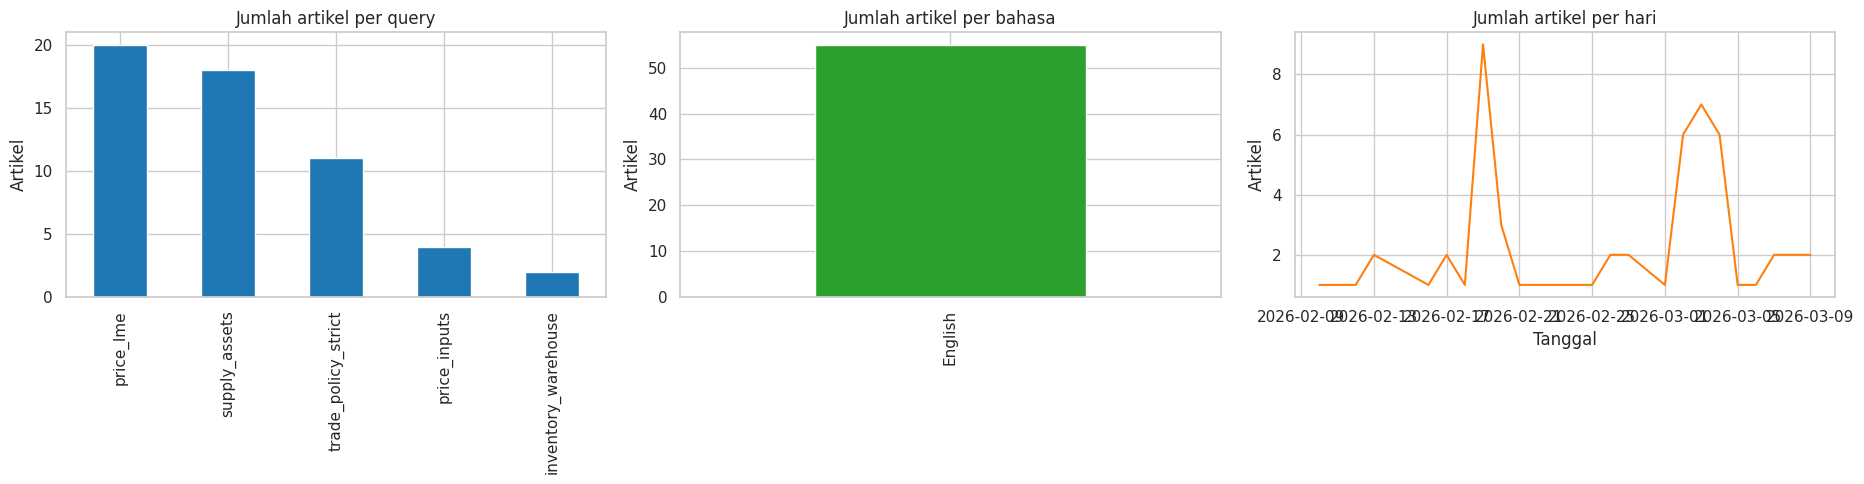

In [6]:
summary = pd.DataFrame([
    {"Metrik": "Jumlah artikel mentah", "Nilai": int(len(raw_news)), "Makna": "Jumlah hasil gabungan dari semua query dan bahasa."},
    {"Metrik": "Jumlah artikel bersih", "Nilai": int(len(news)), "Makna": "Setelah normalisasi dan dedup title+url."},
    {"Metrik": "Rentang tanggal mulai", "Nilai": str(pd.to_datetime(news["news_datetime"]).min().date()), "Makna": "Tanggal artikel paling lama di sample."},
    {"Metrik": "Rentang tanggal akhir", "Nilai": str(pd.to_datetime(news["news_datetime"]).max().date()), "Makna": "Tanggal artikel paling baru di sample."},
    {"Metrik": "Bahasa unik", "Nilai": int(news["language"].nunique()), "Makna": "Semakin konsisten, semakin mudah discore dan diaudit."},
    {"Metrik": "Domain unik", "Nilai": int(news["domain"].nunique()), "Makna": "Semakin banyak domain, coverage makin luas tetapi potensi noise juga naik."},
    {"Metrik": "Share suspected noise", "Nilai": round(float(news["is_suspected_noise"].mean()), 4), "Makna": "Semakin kecil semakin baik."},
])
display(summary)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

news["query_group"].value_counts().sort_values(ascending=False).plot(kind="bar", ax=axes[0], color="tab:blue")
axes[0].set_title("Jumlah artikel per query")
axes[0].set_xlabel("")
axes[0].set_ylabel("Artikel")

news["language"].replace("", "unknown").value_counts().sort_values(ascending=False).plot(kind="bar", ax=axes[1], color="tab:green")
axes[1].set_title("Jumlah artikel per bahasa")
axes[1].set_xlabel("")
axes[1].set_ylabel("Artikel")

daily_counts = news.groupby("news_date").size()
axes[2].plot(pd.to_datetime(daily_counts.index), daily_counts.values, color="tab:orange", linewidth=1.5)
axes[2].set_title("Jumlah artikel per hari")
axes[2].set_xlabel("Tanggal")
axes[2].set_ylabel("Artikel")

plt.tight_layout()
plt.show()


## 2) Audit relevansi: apakah query ini sudah cukup presisi?

Kategori yang dipakai sekarang:
- `direct`: sinyal harga/pasar/policy aluminium terlihat jelas di title/snippet.
- `indirect`: masih ada anchor aluminium, lalu ada sinyal pasar/logistik/supply yang masuk akal.
- `industry`: berita industri aluminium yang layak dibaca, tetapi belum tentu layak jadi fitur model.
- `context_only`: konteks bisnis umum tanpa anchor aluminium yang cukup kuat.
- `other`: tidak terlihat relevan untuk bisnis aluminium.

Tambahan audit v4:
- `title_model_signal`: title sendiri sudah cukup kuat untuk dipakai sebagai kandidat model.
- `title_industry_context`: title layak dibaca sebagai konteks industri.
- `domain_quality`: domain dibagi menjadi `high_signal`, `neutral`, dan `low_signal`.

Target sederhananya:
- `candidate_model` harus lebih sedikit tetapi lebih bersih.
- domain `low_signal` tidak boleh bocor ke kandidat model.
- `candidate_readonly` dipakai untuk konteks, bukan untuk fitur model.


relevance,query_group,context_only,direct,indirect,industry,other
0,inventory_warehouse,1,1,0,0,0
1,price_inputs,2,0,0,0,2
2,price_lme,1,3,3,0,13
3,supply_assets,1,2,0,7,8
4,trade_policy_strict,6,2,0,0,3


relevance,query_group,context_only,direct,indirect,industry,other
0,inventory_warehouse,0.500,0.500,0.00,0.000,0.000
1,price_inputs,0.500,0.000,0.00,0.000,0.500
2,price_lme,0.050,0.150,0.15,0.000,0.650
3,supply_assets,0.056,0.111,0.00,0.389,0.444
4,trade_policy_strict,0.545,0.182,0.00,0.000,0.273


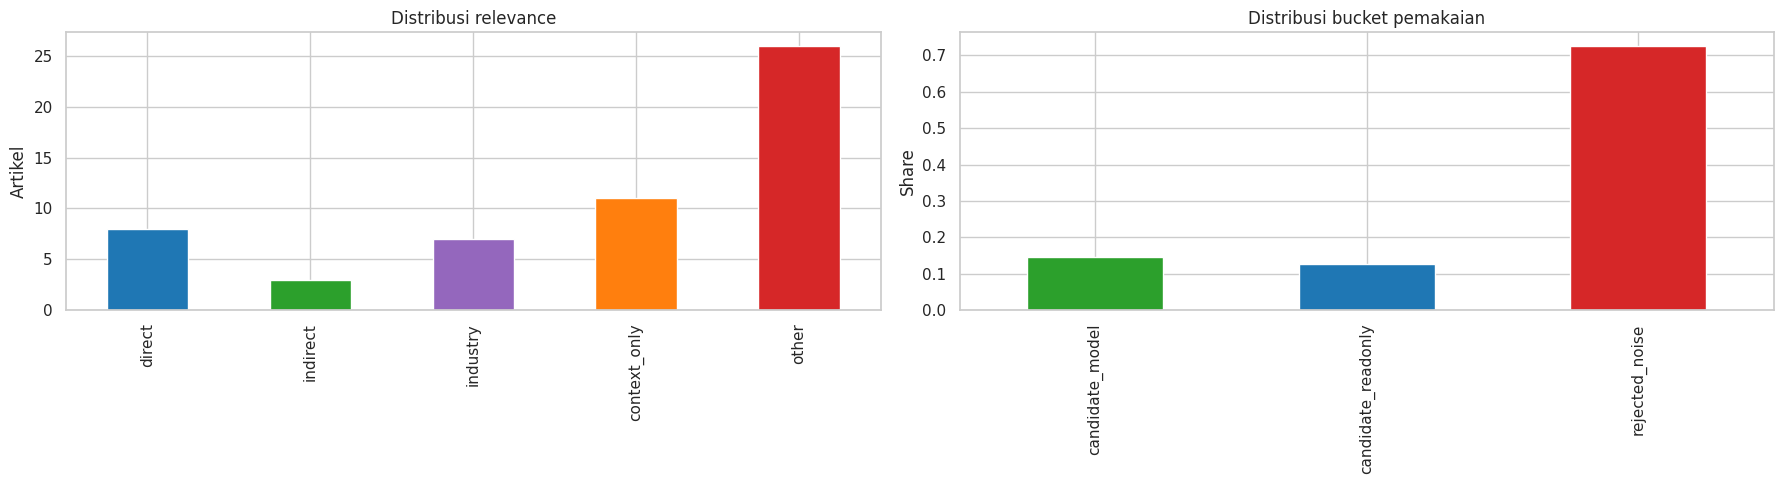

In [7]:
relevance_table = (
    news.groupby(["query_group", "relevance"])
    .size()
    .rename("article_count")
    .reset_index()
)
relevance_pivot = relevance_table.pivot(index="query_group", columns="relevance", values="article_count").fillna(0).astype(int)
relevance_share = relevance_pivot.div(relevance_pivot.sum(axis=1), axis=0).round(3)

display(relevance_pivot.reset_index())
display(relevance_share.reset_index())

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

relevance_order = ["direct", "indirect", "industry", "context_only", "other"]
news["relevance"].value_counts().reindex(relevance_order).fillna(0).plot(
    kind="bar",
    ax=axes[0],
    color=["tab:blue", "tab:green", "tab:purple", "tab:orange", "tab:red"],
)
axes[0].set_title("Distribusi relevance")
axes[0].set_xlabel("")
axes[0].set_ylabel("Artikel")

usage_rate = news["usage_bucket"].value_counts(normalize=True).reindex(
    ["candidate_model", "candidate_readonly", "rejected_noise"]
).fillna(0)
usage_rate.plot(kind="bar", ax=axes[1], color=["tab:green", "tab:blue", "tab:red"])
axes[1].set_title("Distribusi bucket pemakaian")
axes[1].set_xlabel("")
axes[1].set_ylabel("Share")

plt.tight_layout()
plt.show()


In [8]:
top_domains = (
    news.groupby(["domain", "relevance"])
    .size()
    .rename("article_count")
    .reset_index()
    .sort_values("article_count", ascending=False)
)

suspected_noise = news[news["is_suspected_noise"]].copy()

domain_summary = (
    news.groupby(["domain", "domain_quality"])
    .agg(
        article_count=("title", "size"),
        noise_share=("is_suspected_noise", "mean"),
        model_share=("usage_bucket", lambda s: (s == "candidate_model").mean()),
        readonly_share=("usage_bucket", lambda s: (s == "candidate_readonly").mean()),
        direct_share=("relevance", lambda s: (s == "direct").mean()),
        indirect_share=("relevance", lambda s: (s == "indirect").mean()),
        industry_share=("relevance", lambda s: (s == "industry").mean()),
    )
    .sort_values(["article_count", "noise_share"], ascending=[False, False])
    .reset_index()
)

print("Top domain summary")
display(domain_summary.head(20))

print("Contoh suspected noise")
display(
    suspected_noise[
        [
            "news_date", "query_group", "language", "relevance", "usage_bucket",
            "domain_quality", "noise_hits", "finance_noise_hits", "title", "domain"
        ]
    ].head(20)
)


Top domain summary


,domain,domain_quality,article_count,noise_share,model_share,readonly_share,direct_share,indirect_share,industry_share
0,finance.yahoo.com,low_signal,5,1.00,0.00,0.0,0.00,0.000000,0.0
1,hellenicshippingnews.com,high_signal,4,0.25,0.75,0.0,0.75,0.000000,0.0
2,economictimes.indiatimes.com,low_signal,3,1.00,0.00,0.0,0.00,0.333333,0.0
3,themarketsdaily.com,low_signal,3,1.00,0.00,0.0,0.00,0.000000,0.0
4,tradearabia.com,low_signal,2,1.00,0.00,0.0,0.00,0.000000,0.0
5,allafrica.com,neutral,2,0.00,0.00,1.0,0.00,0.000000,1.0
6,gdnonline.com,neutral,2,0.00,0.00,1.0,0.00,0.000000,1.0
7,mining.com,high_signal,2,0.00,1.00,0.0,1.00,0.000000,0.0
8,bicycleretailer.com,low_signal,1,1.00,0.00,0.0,1.00,0.000000,0.0
9,businesstoday.in,low_signal,1,1.00,0.00,0.0,0.00,1.000000,0.0


Contoh suspected noise


,news_date,query_group,language,relevance,usage_bucket,domain_quality,noise_hits,finance_noise_hits,title,domain
0,2026-03-09,price_lme,English,other,rejected_noise,low_signal,"analysts explain, low_signal_domain, metal stocks","analysts explain, metal stocks","What Iran war means for Vedanta , Tata Steel and other metal stocks ? CLSA analysts explain",economictimes.indiatimes.com
2,2026-03-08,price_inputs,English,other,rejected_noise,low_signal,"beverage, low_signal_domain",,Molson Coors Beverage Company ( TAP ) Expects a Significant Dip in 2026 Profit,finance.yahoo.com
3,2026-03-08,supply_assets,English,other,rejected_noise,low_signal,"low_signal_domain, represented at, trade fair",,Bahrain to be represented at Asia no . 1 aluminum trade fair,eturbonews.com
4,2026-03-07,supply_assets,English,other,rejected_noise,neutral,,,"Melissa damage delays Alpart reopening , govt awaiting new timeline - Green | News",jamaica-gleaner.com
5,2026-03-07,price_lme,English,other,rejected_noise,low_signal,"cao sells, low_signal_domain, nasdaq","cao sells, nasdaq","Century Aluminum ( NASDAQ : CENX ) CAO Sells $563 , 300 . 00 in Stock",tickerreport.com
7,2026-03-05,supply_assets,English,other,rejected_noise,low_signal,"dealmaking, low_signal_domain",,"The Gulf is still dealmaking , for now",finance.yahoo.com
9,2026-03-04,price_lme,English,other,rejected_noise,low_signal,"briefing, low_signal_domain",,Breakfast briefing : Insurers dismiss Trump promises,interest.co.nz
10,2026-03-04,supply_assets,English,other,rejected_noise,low_signal,"appointment, leadership, leadership pipeline, low_signal_domain",,Alba boosts Bahraini leadership pipeline through key appointments,tradearabia.com
11,2026-03-04,supply_assets,English,other,rejected_noise,low_signal,"appointment, leadership, leadership pipeline, low_signal_domain",,Alba boosts Bahraini leadership pipeline through key appointments,tradearabia.com
12,2026-03-04,supply_assets,English,context_only,rejected_noise,neutral,watch,,"Daily on Energy : The ratepayer protection pledge , oil and gas price watch , and thoughts from EU Ambassador Neliupšienė on Iran",washingtonexaminer.com


## 3) Audit manual: lihat contoh judulnya langsung

Bagian ini sengaja disediakan supaya mudah menjawab pertanyaan:
apakah GDELT benar-benar menangkap berita aluminium yang berguna, atau malah menarik berita yang absurd?


In [9]:
def sample_titles(frame: pd.DataFrame, label: str, n: int = 12) -> pd.DataFrame:
    cols = [
        "news_date", "query_group", "language", "domain", "domain_quality",
        "relevance", "usage_bucket",
        "core_hits", "context_hits", "industry_hits",
        "title_direct_hits", "title_signal_hits", "title_other_metal_hits",
        "noise_hits", "finance_noise_hits", "title"
    ]
    view = frame[cols].head(n).copy()
    view.insert(0, "kelompok", label)
    return view


direct_examples = sample_titles(news[news["relevance"] == "direct"].sort_values("news_datetime", ascending=False), "direct")
indirect_examples = sample_titles(news[news["relevance"] == "indirect"].sort_values("news_datetime", ascending=False), "indirect")
industry_examples = sample_titles(news[news["relevance"] == "industry"].sort_values("news_datetime", ascending=False), "industry")
noise_examples = sample_titles(news[news["is_suspected_noise"]].sort_values("news_datetime", ascending=False), "suspected_noise")

print("Contoh direct")
display(direct_examples)

print("Contoh indirect")
display(indirect_examples)

print("Contoh industry")
display(industry_examples)

print("Contoh suspected_noise")
display(noise_examples)


Contoh direct


,kelompok,news_date,query_group,language,domain,domain_quality,relevance,usage_bucket,core_hits,context_hits,industry_hits,title_direct_hits,title_signal_hits,title_other_metal_hits,noise_hits,finance_noise_hits,title
8,direct,2026-03-04,inventory_warehouse,English,hellenicshippingnews.com,high_signal,direct,candidate_model,aluminum price,"price, prices, shipping",,aluminum price,"price, prices, shipping",,,,How long will Gulf disruptions support aluminum prices ? | Hellenic Shipping News Worldwide
13,direct,2026-03-04,supply_assets,English,mining.com,high_signal,direct,candidate_model,aluminum price,"force majeure, price",,aluminum price,"force majeure, price",,,,Aluminum price surges to 4 - year high on Bahrain force majeure
14,direct,2026-03-03,supply_assets,English,hellenicshippingnews.com,high_signal,direct,candidate_model,aluminum market,"market, shipping",,aluminum market,"market, shipping",,,,Geopolitical risks in Middle East seen tightening Asian aluminum market | Hellenic Shipping News Worldwide
21,direct,2026-03-02,price_lme,English,mining.com,high_signal,direct,candidate_model,aluminum price,"price, supply",,aluminum price,"price, supply",,,,Aluminum price jumps as Iran conflict puts Middle East supply at risk
33,direct,2026-02-24,price_lme,English,news.metal.com,high_signal,direct,candidate_model,aluminum market,"demand, market",,aluminum market,"demand, market",,,,"[ SMM Analysis ] Global Macro Mildly Positive , Aluminum Market Sees Short - Term Volatility Awaiting Demand Recovery"
34,direct,2026-02-21,trade_policy_strict,English,bicycleretailer.com,low_signal,direct,rejected_noise,aluminum tariff,"tarif, tariff",,aluminum tariff,"tarif, tariff",,"bike, bikes, low_signal_domain",,"Following Supreme Court decision , PeopleForBikes focuses on averting an aluminum tariff"
50,direct,2026-02-16,price_lme,English,hellenicshippingnews.com,high_signal,direct,candidate_model,aluminium tariff,"shipping, tarif, tariff",,aluminium tariff,"shipping, tarif, tariff",,,,Aluminium tariff rollback talk brings little relief | Hellenic Shipping News Worldwide
51,direct,2026-02-13,trade_policy_strict,English,business-standard.com,high_signal,direct,candidate_model,aluminium price,"price, prices, tarif, tariff, tariffs",,aluminium price,"price, prices, tarif, tariff, tariffs",,,,Aluminium prices drop to one - week low on report Trump may ease tariffs


Contoh indirect


,kelompok,news_date,query_group,language,domain,domain_quality,relevance,usage_bucket,core_hits,context_hits,industry_hits,title_direct_hits,title_signal_hits,title_other_metal_hits,noise_hits,finance_noise_hits,title
1,indirect,2026-03-09,price_lme,English,forbes.com,neutral,indirect,candidate_model,aluminum,shipping,,,shipping,,,,"Aluminum Follows Oil , Soaring As Persian Gulf Shipping Is Squeezed"
45,indirect,2026-02-19,price_lme,English,businesstoday.in,low_signal,indirect,rejected_noise,aluminium,"price, prices",,,"price, prices","copper, zinc","low_signal_domain, stock target, stock targets","stock target, stock targets","Hindustan Zinc , Vedanta , Hindalco : Aluminium , zinc , copper prices firm ; stock targets"
49,indirect,2026-02-17,price_lme,English,economictimes.indiatimes.com,low_signal,indirect,rejected_noise,aluminum,"market, price, stockpile, tarif, tariff",,,"market, price, stockpile, tarif, tariff",copper,low_signal_domain,,why copper price falling today explained : Metals market alert : Why copper price is falling today after stockpiles hit 20 - year high and aluminum slips amid tariff uncertainty


Contoh industry


,kelompok,news_date,query_group,language,domain,domain_quality,relevance,usage_bucket,core_hits,context_hits,industry_hits,title_direct_hits,title_signal_hits,title_other_metal_hits,noise_hits,finance_noise_hits,title
6,industry,2026-03-06,supply_assets,English,myedmondsnews.com,neutral,industry,candidate_readonly,aluminum,,smelter,,,,,,Demolition of last Northwest aluminum smelter signals end of an industrial era
18,industry,2026-03-03,supply_assets,English,gdnonline.com,neutral,industry,candidate_readonly,aluminium,,"acquire, agreement",,,,,,Bahrain Business : Alba signs exclusive agreement to acquire Aluminium Dunkerque
19,industry,2026-03-03,supply_assets,English,gdnonline.com,neutral,industry,candidate_readonly,aluminium,,"acquire, agreement",,,,,,Bahrain Business : Alba signs exclusive agreement to acquire Aluminium Dunkerque
23,industry,2026-03-02,supply_assets,English,allafrica.com,neutral,industry,candidate_readonly,alumina,,"alumina refinery, deal, mining, refinery",,,,,,"Nigeria : Federal Govt , AFC Seal $1 . 3bn Alumina Refinery Deal to Drive Mining Sector Transformation"
24,industry,2026-03-02,supply_assets,English,zawya.com,neutral,industry,candidate_readonly,aluminium,,"acquire, acquires, smelter",,,,,,Alba acquires Europe largest primary aluminium smelter
25,industry,2026-03-02,supply_assets,English,nigerianeye.com,neutral,industry,candidate_readonly,alumina,,"alumina refinery, deal, mining, refinery",,,,,,"FG , AFC Sign Landmark $1 . 3bn Deal for Alumina Refinery , Mining Projects - Latest News In Nigeria , Nigeria News Today , Your Online Nigerian Newspaper"
26,industry,2026-03-02,supply_assets,English,allafrica.com,neutral,industry,candidate_readonly,alumina,,deal,,,,,,"Nigeria : Govt , African Finance Corporation Sign Landmark $1 . 3 Billion Alumina Deal"


Contoh suspected_noise


,kelompok,news_date,query_group,language,domain,domain_quality,relevance,usage_bucket,core_hits,context_hits,industry_hits,title_direct_hits,title_signal_hits,title_other_metal_hits,noise_hits,finance_noise_hits,title
0,suspected_noise,2026-03-09,price_lme,English,economictimes.indiatimes.com,low_signal,other,rejected_noise,,,,,,steel,"analysts explain, low_signal_domain, metal stocks","analysts explain, metal stocks","What Iran war means for Vedanta , Tata Steel and other metal stocks ? CLSA analysts explain"
2,suspected_noise,2026-03-08,price_inputs,English,finance.yahoo.com,low_signal,other,rejected_noise,,,,,,,"beverage, low_signal_domain",,Molson Coors Beverage Company ( TAP ) Expects a Significant Dip in 2026 Profit
3,suspected_noise,2026-03-08,supply_assets,English,eturbonews.com,low_signal,other,rejected_noise,aluminum,,,,,,"low_signal_domain, represented at, trade fair",,Bahrain to be represented at Asia no . 1 aluminum trade fair
4,suspected_noise,2026-03-07,supply_assets,English,jamaica-gleaner.com,neutral,other,rejected_noise,,,reopening,,,,,,"Melissa damage delays Alpart reopening , govt awaiting new timeline - Green | News"
5,suspected_noise,2026-03-07,price_lme,English,tickerreport.com,low_signal,other,rejected_noise,aluminum,,,,,,"cao sells, low_signal_domain, nasdaq","cao sells, nasdaq","Century Aluminum ( NASDAQ : CENX ) CAO Sells $563 , 300 . 00 in Stock"
7,suspected_noise,2026-03-05,supply_assets,English,finance.yahoo.com,low_signal,other,rejected_noise,,,deal,,,,"dealmaking, low_signal_domain",,"The Gulf is still dealmaking , for now"
9,suspected_noise,2026-03-04,price_lme,English,interest.co.nz,low_signal,other,rejected_noise,,,,,,,"briefing, low_signal_domain",,Breakfast briefing : Insurers dismiss Trump promises
10,suspected_noise,2026-03-04,supply_assets,English,tradearabia.com,low_signal,other,rejected_noise,,,,,,,"appointment, leadership, leadership pipeline, low_signal_domain",,Alba boosts Bahraini leadership pipeline through key appointments
11,suspected_noise,2026-03-04,supply_assets,English,tradearabia.com,low_signal,other,rejected_noise,,,,,,,"appointment, leadership, leadership pipeline, low_signal_domain",,Alba boosts Bahraini leadership pipeline through key appointments
12,suspected_noise,2026-03-04,supply_assets,English,washingtonexaminer.com,neutral,context_only,rejected_noise,,price,,,price,,watch,,"Daily on Energy : The ratepayer protection pledge , oil and gas price watch , and thoughts from EU Ambassador Neliupšienė on Iran"


## 4) Apakah data ini layak dibawa ke sentiment analysis?

Checklist di bawah ini dibuat supaya keputusan tidak terlalu subjektif.


In [10]:
direct_share = float((news["relevance"] == "direct").mean())
indirect_share = float((news["relevance"] == "indirect").mean())
industry_share = float((news["relevance"] == "industry").mean())
context_only_share = float((news["relevance"] == "context_only").mean())
other_share = float((news["relevance"] == "other").mean())
noise_share = float(news["is_suspected_noise"].mean())
has_core_share = float(news["has_core_term"].mean())
product_event_noise_share = float(news["has_product_event_term"].mean())
finance_noise_share = float(news["has_finance_noise_term"].mean())
candidate_model_share = float((news["usage_bucket"] == "candidate_model").mean())
candidate_readonly_share = float((news["usage_bucket"] == "candidate_readonly").mean())
title_model_signal_share = float(news["title_model_signal"].mean())
low_signal_domain_share = float((news["domain_quality"] == "low_signal").mean())
low_signal_in_model_share = float(
    news.loc[news["usage_bucket"] == "candidate_model", "domain_quality"].eq("low_signal").mean()
) if (news["usage_bucket"] == "candidate_model").any() else 0.0

enough_rows = len(news) >= 30
good_noise = noise_share <= 0.55
good_core = has_core_share >= 0.40
good_relevance = (direct_share + indirect_share) >= 0.25
good_model_share = candidate_model_share >= 0.15
good_product_event = product_event_noise_share <= 0.20
good_finance_noise = finance_noise_share <= 0.15
good_model_domain = low_signal_in_model_share == 0.0

decision = pd.DataFrame([
    {
        "Checklist": "Jumlah artikel sample cukup",
        "Status": "Ya" if enough_rows else "Tidak",
        "Catatan": "EDA tetap butuh volume minimal supaya audit tidak terlalu sempit."
    },
    {
        "Checklist": "Berita direct + indirect sudah mulai usable",
        "Status": "Ya" if good_relevance else "Tidak",
        "Catatan": f"Target minimal 25%. Hasil saat ini = {direct_share + indirect_share:.1%}."
    },
    {
        "Checklist": "Share suspected noise sudah turun",
        "Status": "Ya" if good_noise else "Tidak",
        "Catatan": f"Target maksimal 55%. Hasil saat ini = {noise_share:.1%}."
    },
    {
        "Checklist": "Anchor bisnis aluminium cukup sering muncul",
        "Status": "Ya" if good_core else "Tidak",
        "Catatan": f"Target minimal 40%. Hasil saat ini = {has_core_share:.1%}."
    },
    {
        "Checklist": "Kandidat model sudah cukup ada",
        "Status": "Ya" if good_model_share else "Tidak",
        "Catatan": f"Target minimal 15%. Hasil saat ini = {candidate_model_share:.1%}."
    },
    {
        "Checklist": "Noise produk/event masih rendah",
        "Status": "Ya" if good_product_event else "Tidak",
        "Catatan": f"Target maksimal 20%. Hasil saat ini = {product_event_noise_share:.1%}."
    },
    {
        "Checklist": "Noise komentar finansial masih rendah",
        "Status": "Ya" if good_finance_noise else "Tidak",
        "Catatan": f"Target maksimal 15%. Hasil saat ini = {finance_noise_share:.1%}."
    },
    {
        "Checklist": "Domain low-signal tidak bocor ke kandidat model",
        "Status": "Ya" if good_model_domain else "Tidak",
        "Catatan": f"Target = 0%. Hasil saat ini = {low_signal_in_model_share:.1%}."
    },
])

overview = pd.DataFrame([
    {"Metrik": "Share direct", "Nilai": round(direct_share, 4), "Makna": "Sinyal bisnis aluminium yang paling kuat."},
    {"Metrik": "Share indirect", "Nilai": round(indirect_share, 4), "Makna": "Masih relevan, tetapi tidak sedekat direct."},
    {"Metrik": "Share industry", "Nilai": round(industry_share, 4), "Makna": "Layak dibaca sebagai konteks industri, belum tentu layak jadi fitur model."},
    {"Metrik": "Share context_only", "Nilai": round(context_only_share, 4), "Makna": "Konteks umum tanpa anchor aluminium yang memadai."},
    {"Metrik": "Share other", "Nilai": round(other_share, 4), "Makna": "Tidak terlihat relevan untuk bisnis aluminium."},
    {"Metrik": "Share suspected noise", "Nilai": round(noise_share, 4), "Makna": "Semakin kecil, semakin aman untuk tahap berikutnya."},
    {"Metrik": "Share title_model_signal", "Nilai": round(title_model_signal_share, 4), "Makna": "Title sendiri sudah memberi sinyal yang cukup kuat."},
    {"Metrik": "Share candidate_model", "Nilai": round(candidate_model_share, 4), "Makna": "Inilah share artikel yang paling mungkin layak jadi fitur model."},
    {"Metrik": "Share candidate_readonly", "Nilai": round(candidate_readonly_share, 4), "Makna": "Layak dibaca sebagai konteks, tetapi belum tentu dipakai model."},
    {"Metrik": "Share low-signal domain", "Nilai": round(low_signal_domain_share, 4), "Makna": "Semakin kecil, semakin sedikit artikel dari domain yang sering noisy."},
    {"Metrik": "Share product/event noise", "Nilai": round(product_event_noise_share, 4), "Makna": "Semakin kecil, semakin sedikit noise non-bisnis."},
    {"Metrik": "Share finance-commentary noise", "Nilai": round(finance_noise_share, 4), "Makna": "Semakin kecil, semakin sedikit artikel stock-commentary."},
])

display(overview)
display(decision)

if all([good_relevance, good_noise, good_core, good_model_share, good_product_event, good_finance_noise, good_model_domain]):
    print("Keputusan sementara: GDELT mulai cukup layak untuk lanjut ke tahap sentiment analysis.")
    print("Catatan: kandidat model dan kandidat readonly tetap harus dipisahkan.")
else:
    print("Keputusan sementara: retrieval GDELT masih perlu diperketat sebelum masuk ke sentiment analysis.")
    print("Fokus perbaikan: naikkan kualitas kandidat model, bukan sekadar jumlah artikel.")


,Metrik,Nilai,Makna
0,Share direct,0.1455,Sinyal bisnis aluminium yang paling kuat.
1,Share indirect,0.0545,"Masih relevan, tetapi tidak sedekat direct."
2,Share industry,0.1273,"Layak dibaca sebagai konteks industri, belum tentu layak jadi fitur model."
3,Share context_only,0.2000,Konteks umum tanpa anchor aluminium yang memadai.
4,Share other,0.4727,Tidak terlihat relevan untuk bisnis aluminium.
5,Share suspected noise,0.7273,"Semakin kecil, semakin aman untuk tahap berikutnya."
6,Share title_model_signal,0.2000,Title sendiri sudah memberi sinyal yang cukup kuat.
7,Share candidate_model,0.1455,Inilah share artikel yang paling mungkin layak jadi fitur model.
8,Share candidate_readonly,0.1273,"Layak dibaca sebagai konteks, tetapi belum tentu dipakai model."
9,Share low-signal domain,0.4000,"Semakin kecil, semakin sedikit artikel dari domain yang sering noisy."


,Checklist,Status,Catatan
0,Jumlah artikel sample cukup,Ya,EDA tetap butuh volume minimal supaya audit tidak terlalu sempit.
1,Berita direct + indirect sudah mulai usable,Tidak,Target minimal 25%. Hasil saat ini = 20.0%.
2,Share suspected noise sudah turun,Tidak,Target maksimal 55%. Hasil saat ini = 72.7%.
3,Anchor bisnis aluminium cukup sering muncul,Ya,Target minimal 40%. Hasil saat ini = 41.8%.
4,Kandidat model sudah cukup ada,Tidak,Target minimal 15%. Hasil saat ini = 14.5%.
5,Noise produk/event masih rendah,Ya,Target maksimal 20%. Hasil saat ini = 16.4%.
6,Noise komentar finansial masih rendah,Ya,Target maksimal 15%. Hasil saat ini = 14.5%.
7,Domain low-signal tidak bocor ke kandidat model,Ya,Target = 0%. Hasil saat ini = 0.0%.


Keputusan sementara: retrieval GDELT masih perlu diperketat sebelum masuk ke sentiment analysis.
Fokus perbaikan: naikkan kualitas kandidat model, bukan sekadar jumlah artikel.


In [11]:
candidate_model_news = news[news["usage_bucket"] == "candidate_model"].copy()
candidate_readonly_news = news[news["usage_bucket"] == "candidate_readonly"].copy()
rejected_noise_news = news[news["usage_bucket"] == "rejected_noise"].copy()

candidate_model_news.to_csv(STAGING_DIR / "gdelt_eda_candidate_model_news_v4.csv", index=False)
candidate_readonly_news.to_csv(STAGING_DIR / "gdelt_eda_candidate_readonly_news_v4.csv", index=False)
rejected_noise_news.to_csv(STAGING_DIR / "gdelt_eda_rejected_noise_news_v4.csv", index=False)

bucket_summary = pd.DataFrame([
    {
        "Bucket": "candidate_model",
        "Rows": int(len(candidate_model_news)),
        "Makna": "Paling layak dibawa ke tahap sentiment scoring untuk fitur model."
    },
    {
        "Bucket": "candidate_readonly",
        "Rows": int(len(candidate_readonly_news)),
        "Makna": "Layak dibaca sebagai konteks industri, tetapi jangan otomatis masuk model."
    },
    {
        "Bucket": "rejected_noise",
        "Rows": int(len(rejected_noise_news)),
        "Makna": "Sebaiknya dibuang dari pipeline utama."
    },
])

display(bucket_summary)

print("Contoh candidate_model")
display(candidate_model_news[["news_date", "query_group", "language", "relevance", "domain_quality", "domain", "title"]].head(20))

print("Contoh candidate_readonly")
display(candidate_readonly_news[["news_date", "query_group", "language", "relevance", "domain_quality", "domain", "title"]].head(20))

print("Contoh rejected_noise")
display(rejected_noise_news[["news_date", "query_group", "language", "relevance", "domain_quality", "domain", "title"]].head(20))


,Bucket,Rows,Makna
0,candidate_model,8,Paling layak dibawa ke tahap sentiment scoring untuk fitur model.
1,candidate_readonly,7,"Layak dibaca sebagai konteks industri, tetapi jangan otomatis masuk model."
2,rejected_noise,40,Sebaiknya dibuang dari pipeline utama.


Contoh candidate_model


,news_date,query_group,language,relevance,domain_quality,domain,title
1,2026-03-09,price_lme,English,indirect,neutral,forbes.com,"Aluminum Follows Oil , Soaring As Persian Gulf Shipping Is Squeezed"
8,2026-03-04,inventory_warehouse,English,direct,high_signal,hellenicshippingnews.com,How long will Gulf disruptions support aluminum prices ? | Hellenic Shipping News Worldwide
13,2026-03-04,supply_assets,English,direct,high_signal,mining.com,Aluminum price surges to 4 - year high on Bahrain force majeure
14,2026-03-03,supply_assets,English,direct,high_signal,hellenicshippingnews.com,Geopolitical risks in Middle East seen tightening Asian aluminum market | Hellenic Shipping News Worldwide
21,2026-03-02,price_lme,English,direct,high_signal,mining.com,Aluminum price jumps as Iran conflict puts Middle East supply at risk
33,2026-02-24,price_lme,English,direct,high_signal,news.metal.com,"[ SMM Analysis ] Global Macro Mildly Positive , Aluminum Market Sees Short - Term Volatility Awaiting Demand Recovery"
50,2026-02-16,price_lme,English,direct,high_signal,hellenicshippingnews.com,Aluminium tariff rollback talk brings little relief | Hellenic Shipping News Worldwide
51,2026-02-13,trade_policy_strict,English,direct,high_signal,business-standard.com,Aluminium prices drop to one - week low on report Trump may ease tariffs


Contoh candidate_readonly


,news_date,query_group,language,relevance,domain_quality,domain,title
6,2026-03-06,supply_assets,English,industry,neutral,myedmondsnews.com,Demolition of last Northwest aluminum smelter signals end of an industrial era
18,2026-03-03,supply_assets,English,industry,neutral,gdnonline.com,Bahrain Business : Alba signs exclusive agreement to acquire Aluminium Dunkerque
19,2026-03-03,supply_assets,English,industry,neutral,gdnonline.com,Bahrain Business : Alba signs exclusive agreement to acquire Aluminium Dunkerque
23,2026-03-02,supply_assets,English,industry,neutral,allafrica.com,"Nigeria : Federal Govt , AFC Seal $1 . 3bn Alumina Refinery Deal to Drive Mining Sector Transformation"
24,2026-03-02,supply_assets,English,industry,neutral,zawya.com,Alba acquires Europe largest primary aluminium smelter
25,2026-03-02,supply_assets,English,industry,neutral,nigerianeye.com,"FG , AFC Sign Landmark $1 . 3bn Deal for Alumina Refinery , Mining Projects - Latest News In Nigeria , Nigeria News Today , Your Online Nigerian Newspaper"
26,2026-03-02,supply_assets,English,industry,neutral,allafrica.com,"Nigeria : Govt , African Finance Corporation Sign Landmark $1 . 3 Billion Alumina Deal"


Contoh rejected_noise


,news_date,query_group,language,relevance,domain_quality,domain,title
0,2026-03-09,price_lme,English,other,low_signal,economictimes.indiatimes.com,"What Iran war means for Vedanta , Tata Steel and other metal stocks ? CLSA analysts explain"
2,2026-03-08,price_inputs,English,other,low_signal,finance.yahoo.com,Molson Coors Beverage Company ( TAP ) Expects a Significant Dip in 2026 Profit
3,2026-03-08,supply_assets,English,other,low_signal,eturbonews.com,Bahrain to be represented at Asia no . 1 aluminum trade fair
4,2026-03-07,supply_assets,English,other,neutral,jamaica-gleaner.com,"Melissa damage delays Alpart reopening , govt awaiting new timeline - Green | News"
5,2026-03-07,price_lme,English,other,low_signal,tickerreport.com,"Century Aluminum ( NASDAQ : CENX ) CAO Sells $563 , 300 . 00 in Stock"
7,2026-03-05,supply_assets,English,other,low_signal,finance.yahoo.com,"The Gulf is still dealmaking , for now"
9,2026-03-04,price_lme,English,other,low_signal,interest.co.nz,Breakfast briefing : Insurers dismiss Trump promises
10,2026-03-04,supply_assets,English,other,low_signal,tradearabia.com,Alba boosts Bahraini leadership pipeline through key appointments
11,2026-03-04,supply_assets,English,other,low_signal,tradearabia.com,Alba boosts Bahraini leadership pipeline through key appointments
12,2026-03-04,supply_assets,English,context_only,neutral,washingtonexaminer.com,"Daily on Energy : The ratepayer protection pledge , oil and gas price watch , and thoughts from EU Ambassador Neliupšienė on Iran"
